# Multi-region Sparse Component Analysis (**mSCA**) - reaching data

* This notebook will run mSCA on data gathered from the dorsal premotor and primary motor cortices of a macaque monkey performing a delayed center-out-reach-and-return task.
* The neural activity has been binned at 10 ms.
* The dataset was gathered by Matthew Perich and Lee Miller at Northwestern University.

## Required package installations
* Follow the installation instructions in `README.md` before running the code below.

## Data formatting and example
* In order to fit mSCA and infer latents, your data should be in the following format:
    ```
    X = { 
        "region_1": [trial_1, trial_2, ..., trial_M], 
        "region_2": [trial_1, trial_2, ..., trial_M]
    }
    ```
* The keys of `X` should correspond to the names of the regions in your dataset.
* The values of `X` should be lists of `np.float32` arrays of shape `(t_j x N_i)`.
    * `t_j` is the number of time-points on trial `j`.
    * `N_i` is the number of neurons in region `i`.

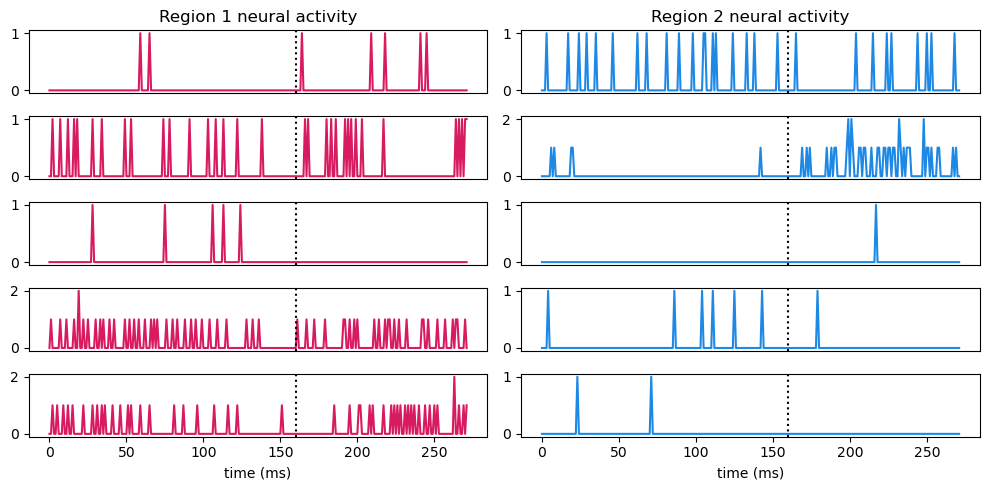

In [1]:
import matplotlib.pyplot as plt
from msca import *

# If you're trying to run this notebook without the data, this will fail
data = torch.load("./data/x.pt", weights_only=False)

# Grab only the neural data
X = {
    "M1": [x.astype("float32") for x in data["M1"]],
    "PMd": [x.astype("float32") for x in data["PMd"]],
}

# Remove weird neuron from pmd
X["PMd"] = [np.concatenate([x[:,:23], x[:,23+1:]], axis=1) for x in X['PMd']]

# Visualization + example accessing attributes of X
colors = ["#D81B60", "#1E88E5"]
num_viz = 5
fig, axs = plt.subplots(num_viz, 2, figsize=(10, 5))
for i in range(num_viz):
    axs[i, 0].plot(X["M1"][0][:, i], c=colors[0])
    axs[i, 1].plot(X["PMd"][0][:, i], c=colors[1])

    axs[i, 0].axvline(data["move_idxs"][0], c="k", ls=":")
    axs[i, 1].axvline(data["move_idxs"][0], c="k", ls=":")

    if i == 0:
        axs[i, 0].set_title("Region 1 neural activity")
        axs[i, 1].set_title("Region 2 neural activity")

    if i < num_viz - 1:
        axs[i, 0].set_xticks([])
        axs[i, 1].set_xticks([])
    else:
        axs[i, 0].set_xlabel("time (ms)")
        axs[i, 1].set_xlabel("time (ms)")
fig.tight_layout()

## Training mSCA

* We're now going to train mSCA

* If your data hasn't been pre-smoothed or trial-averaged in any way, add `loss_func="Poisson"` to the arguments passed into `mSCA()`.

* We have provided what we think are good defaults, but if you want to toggle any of the following hyperparameters `lam_sparse`, `lam_orthog`, or `lam_region`, you can pass your desired value as an argument to `mSCA()`. It's a generally a good idea to keep the values you use within the range [0.0, 1.0].

* Depending on the size of your dataset, `mSCA` can take a large amount of time to train. It's recommended that you save a copy of the model.

In [2]:
msca, losses = mSCA(n_components=20, loss_func="Poisson", n_epochs=6000).fit(X)

# Save trained mSCA model - do this before refining time-delays in case you want to try different thresholds
save_folder = "."
msca.save(f"{save_folder}/msca_reaching.pt")

/Users/andrewulmer/nuin/research/mSCA/msca/architectures.py:173: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


Using region-weights = {'M1': 1.4317243099212646, 'PMd': 0.7683197259902954}
Using lam_sparse = 0.20674633979797363
Using lam_orthog = 4485.544819078947
Using lam_region = 0.0


100%|██████████| 6000/6000 [1:16:27<00:00,  1.31it/s]


## Visualize the losses to ensure the model converged

Text(0.5, 0, 'training epoch')

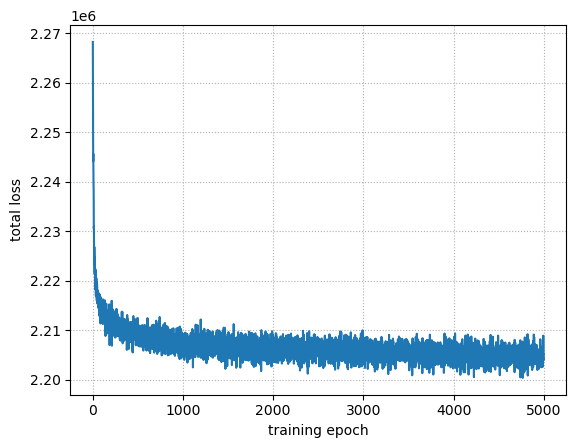

In [3]:
# Concatenate and sum the losses (reconstruction, latent sparsity, region, sparsity, and orthogonality)
loss = losses['total_loss']

# Plot the total loss up until the "post-hoc" scaling compensation stage
plt.plot(loss[:-msca.post_hoc_epoch])
plt.grid(ls=":");
plt.ylabel("total loss");
plt.xlabel("training epoch")

## Inferring latents with the trained mSCA model
* We're now going to use the trained mSCA model to infer latents and compare them to the ground-truth latents and corresponding time-delays.

* **Note**:
    * The recovered latents might appear a little bent when compared to the ground-truth. This is due to the non-linearities in the encoder. On real datasets (non-simulated), we've seen these non-linearities help find sparser, more interpretable latents.
    
    * Also, the inferred latents may be flipped in sign (+1 or -1) when compared to the ground-truth.

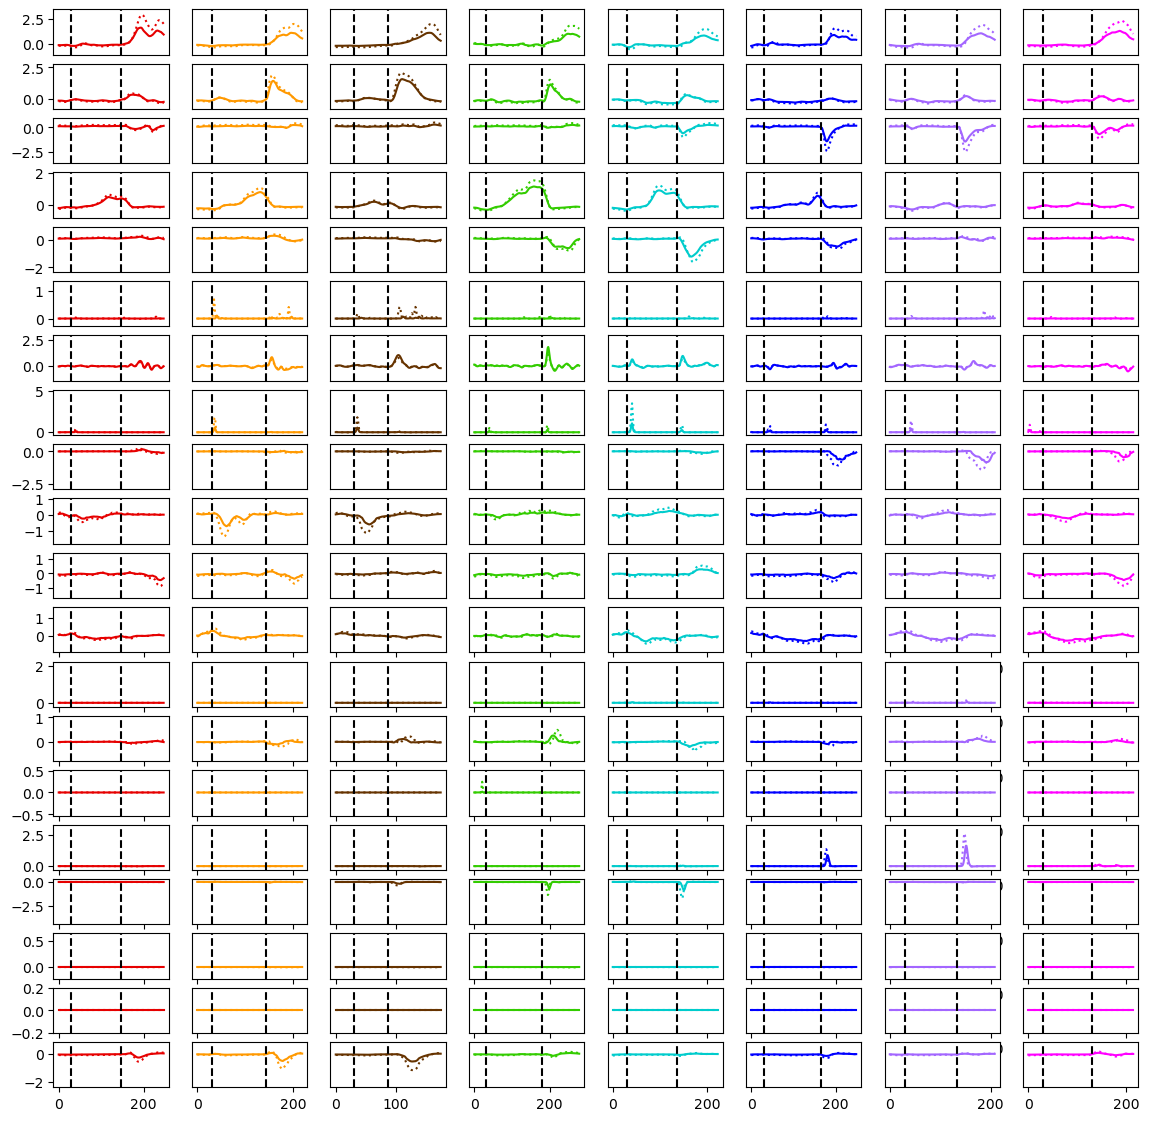

In [22]:
Z = msca.transform(X)

# Grab a random trial
fig, axs = plt.subplots(20, 8, figsize=(14, 14))

colors = [
    "#e60000",
    "#ff9900",
    "#663300",
    "#33cc00",
    "#00cccc",
    "#0000ff",
    "#a366ff",
    "#ff00ff",
]

# t = [3, 9, 0, 26, 7, 0, 10, 30]
# t = [47, 19, 41, 53, 66, 36, 34, 49]

for reach_dir in range(8):
    # Select a random trial from that reach direction
    trial_idx = np.random.choice(np.where(data["reach_dirs"].astype("int32") == reach_dir)[0])
    # trial_idx = t[reach_dir]
    min_bounds = np.minimum(
        np.concatenate(Z["M1"], axis=0).min(axis=0),
        np.concatenate(Z["PMd"], axis=0).min(axis=0),
    )
    max_bounds = np.maximum(
        np.concatenate(Z["M1"], axis=0).max(axis=0),
        np.concatenate(Z["PMd"], axis=0).max(axis=0),
    )
    for i, j in enumerate(range(20)):
        axs[i, reach_dir].plot(
            Z["M1"][trial_idx][:, j], color=colors[reach_dir]
        )
        axs[i, reach_dir].plot(
            Z["PMd"][trial_idx][:, j], color=colors[reach_dir], ls=":"
        )
        axs[i, reach_dir].set_ylim(min_bounds[j]-0.2, max_bounds[j]+0.2)
        
        # axs[i, reach_dir].set_ylim(-3,3)

        if reach_dir > 0:
            axs[i, reach_dir].set_yticks([])
        if i < 11:
            axs[i, reach_dir].set_xticks([])

        # Plot lines for go and target
        axs[i, reach_dir].axvline(
            x=data["go_idxs"][trial_idx] - msca.filter_len,
            color="black",
            ls="--",
        )
        axs[i, reach_dir].axvline(
            x=data["tgt_idxs"][trial_idx] - msca.filter_len,
            color="black",
            ls="--",
        )

## Validating the learned time-delays
* We don't want to interpret time-delays that do not generalize well to held-out data.

* To avoid this, and avoid holding out data from our analysis, we developed a bootstrapping approach that scores time-delays on how well they generalize to *pseudo*-held-out data.

    * The details of this will be covered in `full_demo.ipynb`.

* We can use the results from this approach to prune those time-delays that do not meaningfully improve our ability to reconstruct neural activity input to mSCA.

* Part of the pruning process involves setting a threshold value. A higher threshold value corresponds to a stricter criterion i.e.:

    * For a high threshold, a learned time-delay must substantially improve prediction performance of pseudo-held-out data.

    * For a lower threshold, a learned time-delay must only marginally improve prediction performance of pseudo-held-out data


  0%|          | 0/20 [00:00<?, ?it/s]W0211 23:30:04.622000 11204 site-packages/torch/_dynamo/convert_frame.py:844] [0/8] torch._dynamo hit config.cache_size_limit (8)
W0211 23:30:04.622000 11204 site-packages/torch/_dynamo/convert_frame.py:844] [0/8]    function: 'forward' (/Users/andrewulmer/nuin/research/mSCA/msca/filters.py:124)
W0211 23:30:04.622000 11204 site-packages/torch/_dynamo/convert_frame.py:844] [0/8]    last reason: 0/0: GLOBAL_STATE changed: grad_mode 
W0211 23:30:04.622000 11204 site-packages/torch/_dynamo/convert_frame.py:844] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0211 23:30:04.622000 11204 site-packages/torch/_dynamo/convert_frame.py:844] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
100%|██████████| 20/20 [4:05:31<00:00, 736.60s/it]


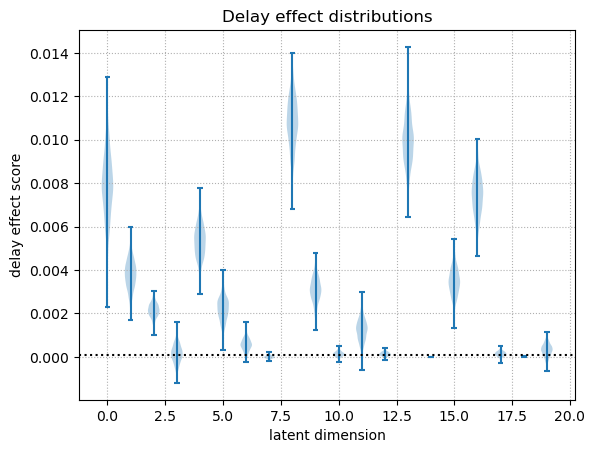

In [5]:
# Find the effect each time-delay has on reconstruction of pseudo-held-out
delay_effects = bootstrap_delays_decoder(msca, X, num_bootstraps=1000)

# Set the threshold to use for pruning delays
threshold = 0.0001

# Plot the distribition of delay effects for each dimension
plt.violinplot(
    [v for v in delay_effects.values()], positions=[k for k in delay_effects.keys()]
)
plt.grid(ls=":")
plt.xlabel("latent dimension")
plt.ylabel("delay effect score")
plt.axhline(y=threshold, ls=":", c="k")
plt.title("Delay effect distributions")

# Iterate through dimensions and prune out those delays that don't fit our criterion
for i in range(msca.n_components):
    mean, lower = mean_confidence_interval(delay_effects[i])
    if lower <= threshold:
        msca.model.filters.mus.data[i] = 0

## Inferring latents with the refined mSCA model
* We're now going to visualize the latents once more, but this time using the refined time-delays.

tensor([ -5.5743,   1.5751,  -0.8450,   0.0000,  -4.4121,   6.0620,   0.0000,
          0.0000,   9.9517,   4.5129,   0.0000,  -3.5980,   0.0000, -11.3032,
          0.0000,   3.3654,   3.8250,   0.0000,   0.0000,   0.0000])


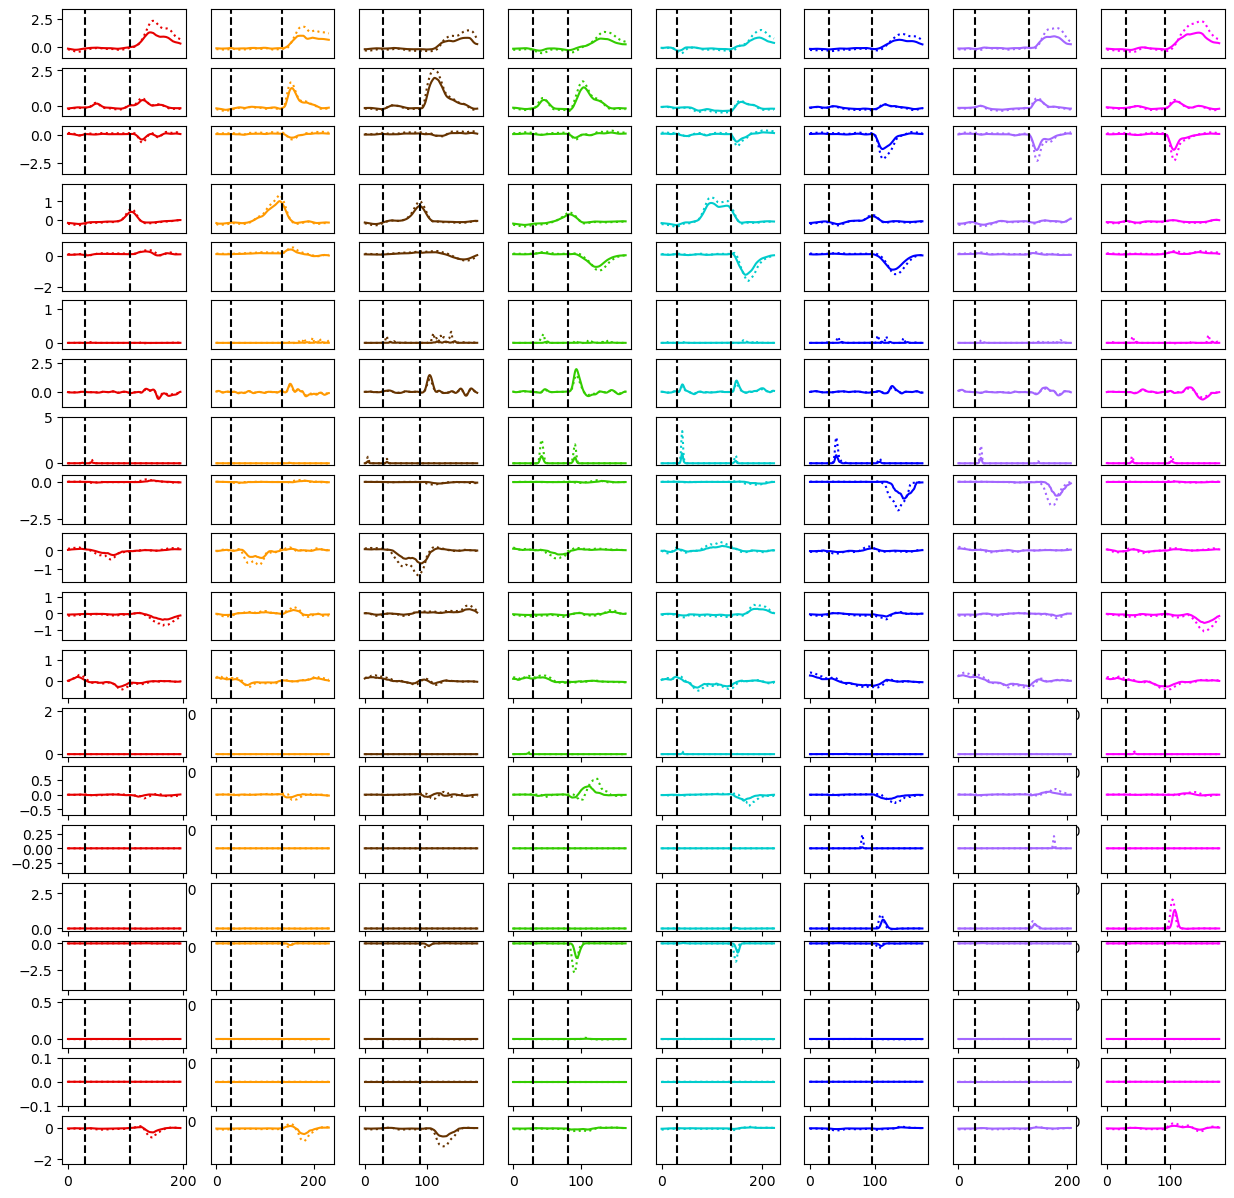

In [20]:
# First infer the latents
Z = msca.transform(X)
# Grab a random trial
fig, axs = plt.subplots(20, 8, figsize=(15, 15))

colors = [
    "#e60000",
    "#ff9900",
    "#663300",
    "#33cc00",
    "#00cccc",
    "#0000ff",
    "#a366ff",
    "#ff00ff",
]

# t = [3, 9, 0, 26, 7, 0, 10, 30]
t = [47, 19, 41, 53, 66, 36, 34, 49]

for reach_dir in range(8):
    # Select a random trial from that reach direction
    trial_idx = np.random.choice(np.where(data["reach_dirs"] == reach_dir)[0])
    # trial_idx = t[reach_dir]
    min_bounds = np.minimum(
        np.concatenate(Z["M1"], axis=0).min(axis=0),
        np.concatenate(Z["PMd"], axis=0).min(axis=0),
    )
    max_bounds = np.maximum(
        np.concatenate(Z["M1"], axis=0).max(axis=0),
        np.concatenate(Z["PMd"], axis=0).max(axis=0),
    )
    for i, j in enumerate(range(20)):
        axs[i, reach_dir].plot(
            Z["M1"][trial_idx][:, j], color=colors[reach_dir]
        )
        axs[i, reach_dir].plot(
            Z["PMd"][trial_idx][:, j], color=colors[reach_dir], ls=":"
        )
        axs[i, reach_dir].set_ylim(min_bounds[j]-0.1, max_bounds[j]+0.1)

        if reach_dir > 0:
            axs[i, reach_dir].set_yticks([])
        if i < 11:
            axs[i, reach_dir].set_xticks([])

        # Plot lines for go and target
        axs[i, reach_dir].axvline(
            x=data["go_idxs"][trial_idx] - msca.filter_len,
            color="black",
            ls="--",
        )
        axs[i, reach_dir].axvline(
            x=data["tgt_idxs"][trial_idx] - msca.filter_len,
            color="black",
            ls="--",
        )

print(msca.model.filters.mus[:, 1] - msca.model.filters.mus[:, 0])

## Check prediction quality
* We're now going to look and see how well the reconstructed neural activity captures the neural activity we input to the model
* The lines in black will be the predictions output by mSCA.

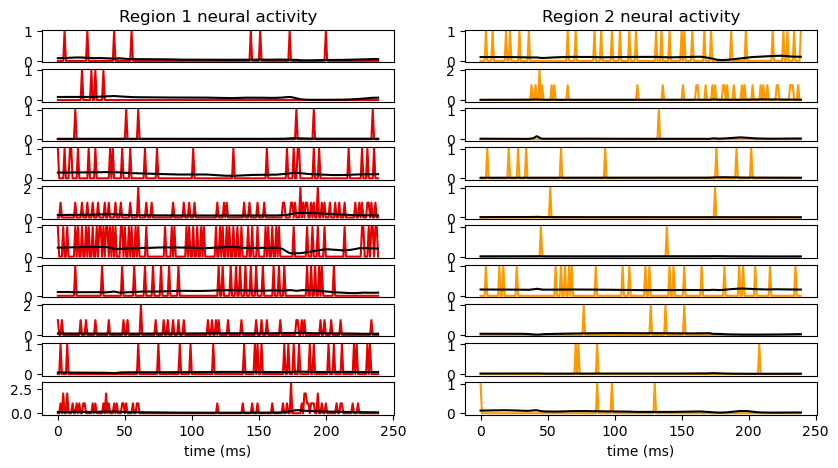

In [19]:
# Grab the reconstructions
X_hat = msca.predict(X)

# Visualization + example accessing attributes of X
num_viz = 10
fig, axs = plt.subplots(num_viz, 2, figsize=(10, 5))
for i in range(num_viz):
    axs[i, 0].plot(X["M1"][1][msca.trunc, i], c=colors[0])
    axs[i, 1].plot(X["PMd"][1][msca.trunc, i], c=colors[1])

    axs[i, 0].plot(X_hat["M1"][1][:, i], c='k')
    axs[i, 1].plot(X_hat["PMd"][1][:, i], c='k')

    if i == 0:
        axs[i, 0].set_title("Region 1 neural activity")
        axs[i, 1].set_title("Region 2 neural activity")

    if i < num_viz - 1:
        axs[i, 0].set_xticks([])
        axs[i, 1].set_xticks([])
    else:
        axs[i, 0].set_xlabel("time (ms)")
        axs[i, 1].set_xlabel("time (ms)")


## Sweeping over sparsity values
### The following is mainly relevant for beta testers at Northwestern

* The code we've provided above is a good starting point to get up and running with mSCA and ensure that your dataset is being loaded correctly.
* We would like to test how robust mSCA is to different hyperparameter settings, namely when using different values for `lam_sparse` and `lam_region`.
    * `lam_sparse` controls the sparsity of the latent representations.
    * `lam_region` controls the sparsity of the latents across brain regions.
* We've provided defaults that we believe work well across a few datasets, but would like to investigate the optimal hyperparameter settings for other datasets as well.
* We'll next demonstrate how to perform a sweep across `lam_sparse`, and include a few different options that may suit you depending on how much data / time you have.
* **Each successive option will take less time to run, but will be more involved in terms of things you have to do.**

### Sweeping on your local machine

In [8]:
# Add path to a folder to store the results of the sweep
sweep_folder = "./check_delete_later/test_sweep/"

# Set the number of components and number of epochs to use in each model fit in the sweep
n_components = 5
n_epochs = 4000

best_sparsity = sparsity_sweep_bootstrap(
    n_components, n_epochs, "Poisson", X, f"{sweep_folder}"
)

print(f"The model with the best sparsity value is stored at {sweep_folder}/msca_{best_sparsity}.pt")

Performing sparsity sweep 🧹 --> saving results to ./check_delete_later/test_sweep/


/Users/andrewulmer/nuin/research/mSCA/msca/architectures.py:173: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


Using region-weights = {'M1': 1.428464412689209, 'PMd': 0.7692617774009705}
Using lam_sparse = 0.0
Using lam_orthog = 88051.201171875
Using lam_region = 0.0


100%|██████████| 1000/1000 [08:47<00:00,  1.90it/s]


RuntimeError: Parent directory ./check_delete_later/test_sweep/ does not exist.

### Sweeping using GPU node on Quest

### Sweeping using multiple short nodes on Quest

* TODO: add note about quest